In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

In [4]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.framework import ops
from tf_utils import load_dataset, random_mini_batches, convert_to_one_hot, predict

%matplotlib inline
np.random.seed(1)

I0000 00:00:1777035886.841513  118337 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777035891.281297  118337 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
y_hat = tf.constant(36, name="y_hat")
y = tf.constant(39, name='y')

loss = tf.Variable((y - y_hat) ** 2, name='loss')

print(loss.numpy())

9


E0000 00:00:1777035892.575261  118337 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


In [6]:
a = tf.constant(2)
b = tf.constant(10)
c = tf.multiply(a, b)
print(c)

tf.Tensor(20, shape=(), dtype=int32)


Linear Function

In [7]:
def linear_function():
    """
    Implement a linear function:
            Initializes X to be a random tensor of shape (3, 1)
            Initializes W to be a random tensor of shape (4, 3)
            Initializes b to be a random tensor of shape (4, 1)
    Returns:
    result -- runs the session for Y = WX + b
    """

    np.random.seed(1)

    """
    Note, to ensure that the "random" numbers generated match the expected results, 
    please create the variables in the order given in the starting code below. 
    (Do not re-arrange the order).
    """

    X = tf.constant(np.random.randn(3, 1), name="X")
    W = tf.constant(np.random.randn(4, 3), name="W")
    b = tf.constant(np.random.randn(4, 1), name="b")
    Y = tf.constant(np.random.randn(4, 1), name="Y")

    result = tf.matmul(W, X) + b
    
    return result

In [8]:
print("result = \n" + str(linear_function()))

result = 
tf.Tensor(
[[-2.15657382]
 [ 2.95891446]
 [-1.08926781]
 [-0.84538042]], shape=(4, 1), dtype=float64)


Computing Sigmoid

In [9]:
def Sigmoid(z):
    """
    Computes the sigmoid of z

    Arguments:
    z -- input value, scalar or vector

    Returns
    results -- the sigmoid of z
    """ 
    x = tf.cast(z, tf.float32, name="x")

    result = tf.math.sigmoid(x)

    return result

In [10]:
print("Sigmoid(0) = " + str(Sigmoid(0)))
print("Sigmoid(12) = " + str(Sigmoid(12)))

Sigmoid(0) = tf.Tensor(0.5, shape=(), dtype=float32)
Sigmoid(12) = tf.Tensor(0.99999386, shape=(), dtype=float32)


In [11]:
def cost(logits, labels):
    """
    Computes the cot using the sigmoid cross entropy

    Arguments:
    logits -- vector containing z, output of the last linear unit (before the final sigmoid activation)
    labels -- vector of labels y (1 or 0)

    Note: What we've been calling "z" and "y" in this class are respectively called "logits" and "labels"
    in the TensorFlow documentation. So logits will feed into z, and labels into y.

    Returns:
    cost -- runs the session of the cost
    """

    z = tf.cast(logits, tf.float32, name="z")
    y = tf.cast(labels, tf.float32, name="y")

    cost = tf.nn.sigmoid_cross_entropy_with_logits(logits=z, labels=y)

    return cost

In [12]:
logits = np.array([0.2, 0.4, 0.7, 0.9])

cost = cost(logits, np.array([0,0,1,1]))
print("Cost = " + str(cost))

Cost = tf.Tensor([0.79813886 0.91301525 0.40318605 0.34115386], shape=(4,), dtype=float32)


Using One Hot Encoding

In [13]:
def one_hot_matrix(labels, C):
    """
    Creates a matrix where the i_th row corresponds to the ith class number and the jth column
                     corresponds to the jth training example. So if example j had a label i. Then entry (i, j)
                     will be 1.
    Arguments:
    labels -- vector containing the labels
    C -- number of classes, the depth of the one-hot dimension

    Returns:
    one_hot -- one hot matrix
    """

    C = tf.constant(C, name="C")

    hot_one_encoded = tf.one_hot(labels, depth=C, axis=0)

    return hot_one_encoded

In [14]:
labels = np.array([1, 2, 3, 0, 2, 1])
one_hot = one_hot_matrix(labels, C=4)
print("One hot = \n" + str(one_hot))

One hot = 
tf.Tensor(
[[0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]], shape=(4, 6), dtype=float32)


Initialize with zeros and ones

In [15]:
def ones(shape):
    """
    Creates an array of ones of dimension shape

    Arguments:
    shape -- shape of the array you want to create

    Returns:
    ones -- array containing only ones
    """

    ones = tf.ones(shape)

    return ones

In [16]:
print("Ones = " + str(ones(3)))

Ones = tf.Tensor([1. 1. 1.], shape=(3,), dtype=float32)


# Building your first neural network in tensorflow

Problem statement: SIGNS Dataset

In [17]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

y = 2


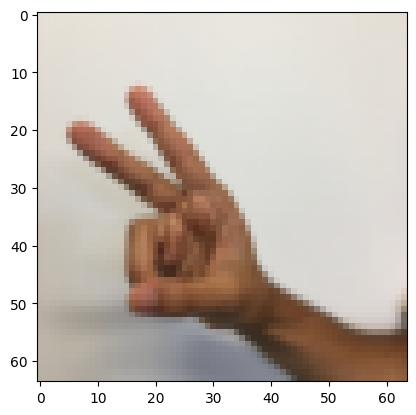

In [18]:
index = 6
plt.imshow(X_train_orig[index])
print("y = " + str(np.squeeze(Y_train_orig[:, index])))

In [19]:
X_train_flatten = X_train_orig.reshape(X_train_orig.shape[0], -1).T
X_test_flatten = X_test_orig.reshape(X_test_orig.shape[0], -1).T

X_train = X_train_flatten/255
X_test = X_test_flatten/255

Y_train = convert_to_one_hot(Y_train_orig, 6)
Y_test = convert_to_one_hot(Y_test_orig, 6)

print("number of training examples = " + str(X_train.shape[1]))
print("number of test examples = " + str(X_test.shape[1]))
print("X_train shape = " + str(X_train.shape))
print("Y_train shape = " + str(Y_train.shape))
print("X_test shape = " + str(X_test.shape))
print("Y_test shape = " + str(Y_test.shape))

number of training examples = 1080
number of test examples = 120
X_train shape = (12288, 1080)
Y_train shape = (6, 1080)
X_test shape = (12288, 120)
Y_test shape = (6, 120)


In [20]:
def create_placeholders(n_x, n_y):
    """
    Creates the placeholders for the tensorflow session.

    Arguments:
    n_x -- scalar, size of an image vector (num_px * num_px = 64 * 64 * 3 = 12288)
    n_y -- scalar, number of classes (from 0 to 5, 50 -> 6)

    Returns:
    X -- placeholder for the data input, of shape [n_x, None] and dtype "tf.float32"
    Y -- placeholder for the input labels, of shape [n_y, None] and dtype "tf.float32"

    Tips:
    - You will use None because it let's us be flexible on the number of examples you will for the placeholders.
      In fact, the number of examples during test/train is different.
    """
    batchsize = 32

    X = tf.zeros(shape = (n_x, batchsize), dtype = tf.float32, name = 'X')
    Y = tf.zeros(shape = (n_y, batchsize), dtype = tf.float32, name = 'Y')
    
    return X, Y

In [21]:
X, Y = create_placeholders(12288, 6)
print("X = " + str(X))
print("Y = " + str(Y))

X = tf.Tensor(
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]], shape=(12288, 32), dtype=float32)
Y = tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]], shape=(6, 32), dtype=float32)


Initializing the Parameters

In [22]:
def intialize_parameters():
    """
    Initializes parameters to build a neural network with tensorflow. The shapes are:
                        W1 : [25, 12288]
                        b1 : [25, 1]
                        w2 : [12, 25]
                        b2 : [12, 1]
                        W3 : [6, 12]
                        b3 : [6, 1]
    
    Returns:
    parameters -- a dictionary of tensors containing W1, b1, W2, b2, W3, b3
    """

    tf.random.set_seed(1)

    initializer = tf.keras.initializers.GlorotUniform(seed=1)

    W1 = tf.Variable(initializer(shape=(25, 12288)), name="W1")
    b1 = tf.Variable(tf.zeros((25, 1)), name="b1")
    W2 = tf.Variable(initializer(shape=(12, 25)), name="W2")
    b2 = tf.Variable(tf.zeros((12, 1)), name="b2")
    W3 = tf.Variable(initializer(shape=(6, 12)), name="W3")
    b3 = tf.Variable(tf.zeros((6, 1)), name="b3")

    parameters = {
        "W1" : W1,
        "b1" : b1,
        "W2" : W2,
        "b2" : b2,
        "W3" : W3,
        "b3" : b3
    }

    return parameters


In [23]:
parameters = intialize_parameters()
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
print("W3 = " + str(parameters["W3"]))
print("b3 = " + str(parameters["b3"]))

W1 = <tf.Variable 'W1:0' shape=(25, 12288) dtype=float32, numpy=
array([[ 1.6709983e-02, -1.7668437e-03,  4.4277869e-03, ...,
        -2.0409860e-02,  1.2577824e-02,  2.0119250e-03],
       [-1.7880250e-02, -1.3661813e-03,  1.7239500e-02, ...,
         1.9963894e-02, -2.1666976e-02,  1.2779485e-02],
       [-1.6950723e-03,  8.4809698e-03, -3.0105226e-03, ...,
         1.6032327e-03, -1.3424931e-02,  1.2222666e-02],
       ...,
       [-3.8248785e-03, -1.9217579e-02, -1.5035600e-02, ...,
         1.9060567e-02,  2.0003520e-02,  1.5377998e-05],
       [ 3.9651226e-03, -1.9923870e-02, -1.6923893e-02, ...,
         3.9070603e-03,  5.1008463e-03, -1.5151719e-02],
       [ 6.1693974e-04,  1.4706045e-02,  7.0033912e-03, ...,
        -1.4057034e-02, -8.5559571e-03,  4.0868819e-03]],
      shape=(25, 12288), dtype=float32)>
b1 = <tf.Variable 'b1:0' shape=(25, 1) dtype=float32, numpy=
array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [

Forward Propagation

In [24]:
def forward_propagation(X, parameters):
    """
    Implements the forward propagation for the model: LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SOFTMAX

    Arguments:
    X -- input dataset placeholder, of shape (input size, number of examples)
    parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3"
                  the shapes are given in initial_parameters.
    
    Returns:
    Z3 -- the output of the last LINEAR unit
    """

    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    Z1 = tf.add(tf.matmul(W1, X), b1)
    a1 = tf.nn.relu(Z1)
    Z2 = tf.add(tf.matmul(W2, a1), b2)
    a2 = tf.nn.relu(Z2)
    Z3 = tf.add(tf.matmul(W3, a2), b3)

    return Z3

In [25]:
X, Y = create_placeholders(12288, 6)
parameters = intialize_parameters()
Z3 = forward_propagation(X, parameters)
print("Z3 = " + str(Z3))

Z3 = tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]], shape=(6, 32), dtype=float32)


In [26]:
def compute_cost(Z3, Y):
    """
    Computes the cost.

    Arguments:
    Z3 -- output of forward propagation (output of the last LINEAR unit), of shape (6, number of examples)
    Y -- "true" labels vector placeholder, same shape as Z3

    Returns:
    cost -- Tensor of the cost function
    """

    z = tf.transpose(Z3)
    y = tf.transpose(Y)

    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=z, labels=y))

    return cost

In [27]:
X, Y = create_placeholders(12288, 6)
parameters = intialize_parameters()
Z3 = forward_propagation(X, parameters)
cost = compute_cost(Z3, Y)
print("Cost = " + str(cost))

Cost = tf.Tensor(0.0, shape=(), dtype=float32)


Backward Propagation and Parameter Updates
Building the Model

In [32]:
def model(X_train, Y_train, X_test, Y_test, learning_rate = 0.0001, num_epochs=1500, minibatch_size=32, print_cost=True):
    """
    Implements a three_layer tensorflow neural network: LINEAR->RELU->LINEAR->RELU->LINEAR->SOFTMAX.

    Arguments:
    X_train -- training set, of shape (input size = 12288, number of training examples = 1080)
    Y_train -- test set, of shape (output size = 6, number of training examples = 1080)
    X_test -- training set, of shape (input size = 12288, number of training examples = 120)
    Y_test -- test set, of shape (output size = 6, number of training examples = 120)
    learning_rate -- learning rrate of the optimization
    num_epochs -- number of epochs of the optimization loop
    minibatch_size -- size of a minibatch
    print_cost -- True to print the cost every 100 epochs

    Returns
    parameters -- parameters learnt by the model. They can then be used to predict
    """

    ops.reset_default_graph()
    tf.random.set_seed(1)
    seed = 3
    (n_x, m) = X_train.shape
    n_y = Y_train.shape[0]
    costs = []

    X, Y = create_placeholders(n_x, n_y)
    
    parameters = intialize_parameters()

    Z3 = forward_propagation(X, parameters)

    

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    cost = compute_cost(Z3, Y)

    for epoch in range(num_epochs):
        epoch_cost = 0
        num_minibatches = int(m/minibatch_size)
        seed = seed + 1
        minibatches = random_mini_batches(X_train, Y_train, minibatch_size, seed)

        for minibatch in minibatches:
            (minibatch_X, minibatch_Y) = minibatch

            with tf.GradientTape() as tape:
                Z3 = forward_propagation(minibatch_X, parameters)
                minibatch_cost = compute_cost(Z3, minibatch_Y)
            
            grads = tape.gradient(minibatch_cost, parameters.values())
            optimizer.apply_gradients(zip(grads, parameters.values()))

            epoch_cost += minibatch_cost / num_minibatches
        
        if print_cost == True and epoch % 100 == 0:
            print("Cost after epcoh %i: %f" % (epoch, epoch_cost))
        if print_cost == True and epoch % 5 == 0:
            costs.append(epoch_cost)
    
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('Iterations (per fives)')
    plt.title("Learning rate = " + str(learning_rate))
    plt.show()

    print("Parameters have been trained!")

    correct_prediction = tf.equal(tf.argmax(Z3), tf.argmax(Y))

    pred = tf.argmax(Z3, axis=0)
    labels = tf.argmax(Y_train, axis=0)
    accuracy = tf.reduce_mean(tf.cast(pred == labels, tf.float32))
    print("Train Accuracy:", accuracy.numpy())
    print("Test Accuracy: ", accuracy.eval({X: X_test, Y: Y_test}))

    return parameters

Cost after epcoh 0: 1.866343
Cost after epcoh 100: 0.743383
Cost after epcoh 200: 0.511412
Cost after epcoh 300: 0.355435
Cost after epcoh 400: 0.230255
Cost after epcoh 500: 0.143218
Cost after epcoh 600: 0.091939
Cost after epcoh 700: 0.066068
Cost after epcoh 800: 0.032792
Cost after epcoh 900: 0.018680
Cost after epcoh 1000: 0.011658
Cost after epcoh 1100: 0.007169
Cost after epcoh 1200: 0.005044
Cost after epcoh 1300: 0.003164
Cost after epcoh 1400: 0.002715


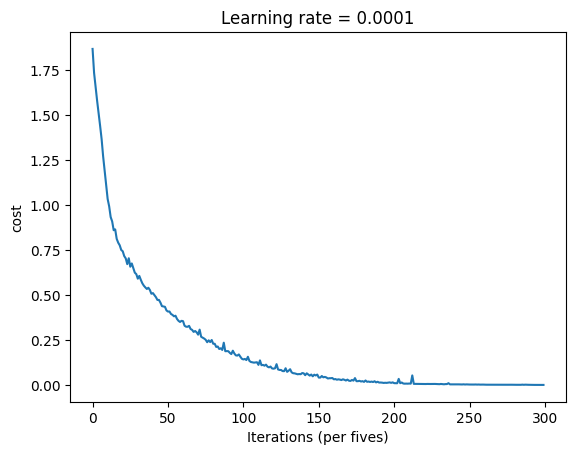

Parameters have been trained!


InvalidArgumentError: {{function_node __wrapped__Equal_device_/job:localhost/replica:0/task:0/device:CPU:0}} Incompatible shapes: [24] vs. [32] [Op:Equal] name: 

In [33]:
parameters = model(X_train, Y_train, X_test, Y_test)